# Phase 4.A — MiVOLO Smoke Test

Goal: feed one real crop through Stages 0-3 and then through MiVOLO. Confirm:

1. The model accepts the face crop + body crop without errors.
2. The output structure matches the README (`age_output`, `gender_class_idx`, `gender_probs`).
3. The predicted age is *plausible* for the visible person.

This is the model's first contact with real dataset crops. If predictions look wildly wrong (age 5 for an adult), there's a preprocessing bug — fix before writing the production filter.

### Notebook config and imports

In [1]:
from __future__ import annotations 

from pathlib import Path 

import cv2 
import numpy as np 
import torch 

from transformers import (AutoConfig,
                          AutoImageProcessor,
                          AutoModelForImageClassification)

from src.components.face_filter import FaceFilter
from src.components.person_detector import PersonDetector
from src.components.pose_filter import PoseFilter
from src.components.quality_filter import QualityFilter

from src.settings.config import (FaceThresholds,
                                 PersonDetectionThresholds,
                                 PoseThresholds,
                                 QualityThresholds)


from src.utils.io import ImageLoader 
from src.logger.custom_logger import logger,configure_logger

19:51:45 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\19-51-45.log


In [2]:
configure_logger(log_level="WARNING")

WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-10/19-51-45.log')

#### Load the four Stage 0-3 filters so we can find a crop that has both face_bbox and person_bbox


In [3]:
quality_filter = QualityFilter(QualityThresholds())
detector = PersonDetector(PersonDetectionThresholds())
pose = PoseFilter(PoseThresholds())
face = FaceFilter(FaceThresholds())
loader = ImageLoader()

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\rsurs/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecu

#### Load MiVOLO

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
config  = AutoConfig.from_pretrained("iitolstykh/mivolo_v2",
                                     trust_remote_code=True)
processor = AutoImageProcessor.from_pretrained("iitolstykh/mivolo_v2",
                                               trust_remote_code=True)

model = AutoModelForImageClassification.from_pretrained("iitolstykh/mivolo_v2",
                                                        trust_remote_code=True,
                                                        dtype=torch.float16).to(device)
model.eval()
print("All models are loaded")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

All models are loaded


### We need images that pass stages 1-3 (quality checks - face detection with InsightFace)

In [5]:
from src.constants import IMAGES_DIR

selected_crop = None 

for path in sorted(IMAGES_DIR.glob("*.png")):
    crop = loader.load(path)

    if not quality_filter.apply(crop).passed:
        continue 

    if not detector.apply(crop).passed:
        continue

    if not pose.apply(crop).passed:
        continue

    face_result = face.apply(crop)
    if not face_result.passed:
        continue 

    if face_result.metrics['n_faces'] > 1:
        continue 
    
    selected_crop = crop 
    break 

if selected_crop is None:
    raise RuntimeError("No image passed Stages 0-3")

print(f"Selected: {selected_crop.crop_id}")
print(f"Image shape: {selected_crop.image.shape}")
print(f"person_bbox (normalized): {selected_crop.extras['person_bbox']}")
print(f"face_bbox (normalized):   {selected_crop.extras['face_bbox']}")


Selected: crop (102)
Image shape: (444, 145, 3)
person_bbox (normalized): (0.01915859244763851, 0.0027274133171886206, 1.0, 0.9986229538917542)
face_bbox (normalized):   (0.15807671382509428, 0.06847373859302418, 0.2643720429519127, 0.11731282655183259)


### Extract the face and body crop in pixel space

In [6]:
H,W = selected_crop.height,selected_crop.width 

def denormalize_bbox(bbox_norm: tuple[float,float,float,float]) -> tuple[int,int,int,int]:
    """Convert the normalized bboxes to pixel coordinates"""
    x1,y1,x2,y2 = bbox_norm
    return (int(x1*W),int(y1*H),int(x2*W),int(y2*H))

face_x1,face_y1,face_x2,face_y2 = denormalize_bbox(selected_crop.extras['face_bbox'])
person_x1,person_y1,person_x2,person_y2 = denormalize_bbox(selected_crop.extras['person_bbox'])

face_crop_rgb = selected_crop.image[face_y1:face_y2, face_x1:face_x2]
person_crop_rgb = selected_crop.image[person_y1:person_y2, person_x1:person_x2]

face_crop_bgr = cv2.cvtColor(face_crop_rgb,cv2.COLOR_RGB2BGR)
person_crop_bgr = cv2.cvtColor(person_crop_rgb,cv2.COLOR_RGB2BGR)

print(f"face_crop shape:   {face_crop_rgb.shape}  pixels: ({face_x1},{face_y1}) -> ({face_x2},{face_y2})")
print(f"person_crop shape: {person_crop_rgb.shape}  pixels: ({person_x1},{person_y1}) -> ({person_x2},{person_y2})")


face_crop shape:   (22, 16, 3)  pixels: (22,30) -> (38,52)
person_crop shape: (442, 143, 3)  pixels: (2,1) -> (145,443)


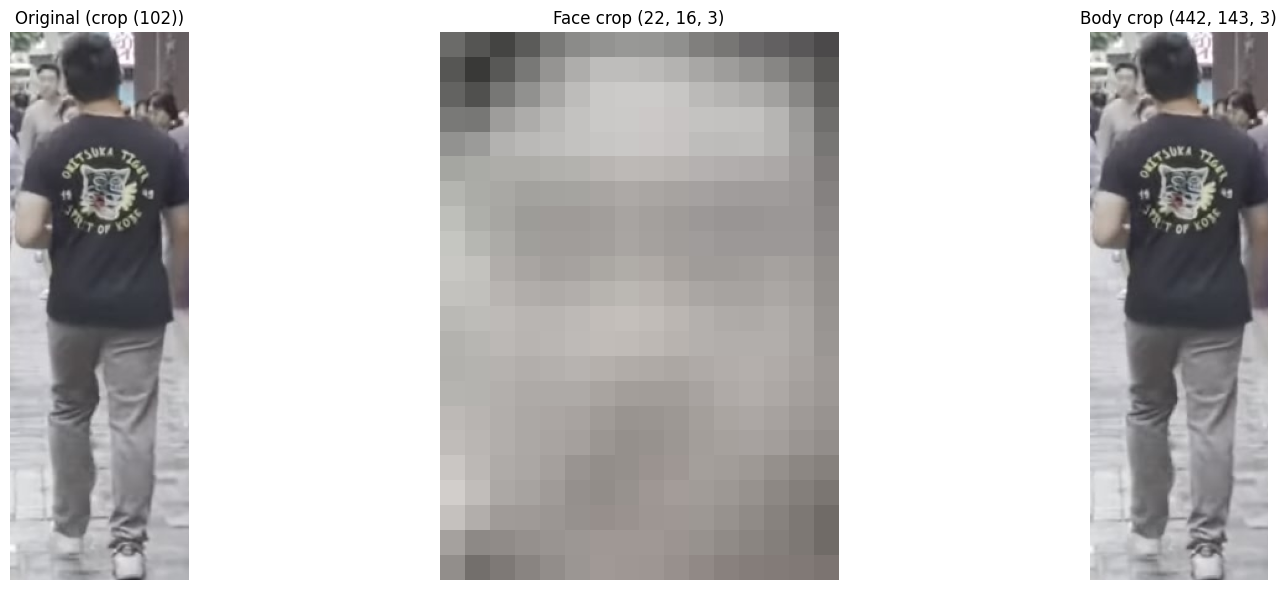

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(selected_crop.image)
axes[0].set_title(f"Original ({selected_crop.crop_id})")
axes[0].axis("off")

axes[1].imshow(face_crop_rgb)
axes[1].set_title(f"Face crop {face_crop_rgb.shape}")
axes[1].axis("off")

axes[2].imshow(person_crop_rgb)
axes[2].set_title(f"Body crop {person_crop_rgb.shape}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Inference with MiVOLO

In [8]:
faces_input = processor(images=[face_crop_bgr])["pixel_values"]
body_input = processor(images=[person_crop_bgr])["pixel_values"]

faces_input = faces_input.to(dtype=model.dtype,device=model.device)
body_input = body_input.to(dtype=model.dtype,device=model.device)

print(f"faces_input shape: {faces_input.shape}, dtype: {faces_input.dtype,} device:{faces_input.device}")
print(f"body_input shape:  {body_input.shape}")

with torch.no_grad():
    output = model(faces_input=faces_input,
                   body_input=body_input,
                   return_dict=True)

print(f"Output type: {type(output).__name__}")
print(f"Output attributes: {[k for k in dir(output) if not k.startswith('_')]}")


faces_input shape: torch.Size([1, 3, 384, 384]), dtype: (torch.float16,) device:cuda:0
body_input shape:  torch.Size([1, 3, 384, 384])
Output type: MiVOLOOutput
Output attributes: ['age_output', 'clear', 'copy', 'fromkeys', 'gender_class_idx', 'gender_probs', 'get', 'head_outputs', 'items', 'keys', 'move_to_end', 'pop', 'popitem', 'raw_age_output', 'raw_gender_output', 'setdefault', 'to_tuple', 'update', 'values']


### Checking MiVOLO prediction

In [9]:
age = output.age_output[0].item()
print(f"Predicted age: {age:.1f} years")

gender_idx = output.gender_class_idx[0].item()
gender_prob = output.gender_probs[0].item()
gender = config.gender_id2label[gender_idx]
print(f"Predicted gender: {gender} ({gender_prob:.0%} confidence)")

Predicted age: 27.1 years
Predicted gender: male (99% confidence)
